In [25]:
import numpy as np
import matplotlib.pyplot as plt
import random
import pandas as pd
import json

### Carregando os dados

In [26]:
x = np.load("CARACTERES COMPLETO/X.npy")
x = x.reshape(x.shape[0], -1)
Y = np.load("CARACTERES COMPLETO/Y_classe.npy")
Y.shape[1]
x.shape[1]

120

## Backpropagation

$$\frac{\partial E}{\partial W1} = \frac{\partial E}{\partial \hat y} * \frac{\partial \hat y}{\partial Z2} * \frac{\partial Z2}{\partial W2} * \frac{\partial W2}{\partial f1} * \frac{\partial f1}{\partial Z1} * \frac{\partial Z1}{\partial W1} $$

$$ \delta_2 = \frac{\partial E}{\partial \hat y} * \frac{\partial \hat y}{\partial Z2}$$

Partindo de $\hat y$:
$$\hat y =\frac{e^{z_{21}}}{e^{z_{21}} + e^{z_{22}}}$$

Temos que $\frac{\partial \hat y}{\partial Z2}$ é:
$$u = e^{z_{21}}  \space \space \space \space \space \space v = e^{z_{21}} + e^{z_{22}}$$


$$\hat y = \frac{u}{v}$$
$$
\frac{\partial{\frac{u}{v}}}{\partial{Z2}}
=
\frac{u'v - uv'}{v^2} = \frac{
e^{z_{21}}(e^{z_{21}}+e^{z_{22}})
-
e^{z_{21}}e^{z_{21}}
}{
(e^{z_{21}}+e^{z_{22}})^2
}
=
\frac{
e^{z_{21}}e^{z_{22}}
}{
(e^{z_{21}}+e^{z_{22}})^2
}
$$
Agora calculamos:

$$
1-\hat y
$$

Substituindo:

$$
1-
\frac{e^{z_{21}}}
{e^{z_{21}}+e^{z_{22}}}
$$

Colocando no mesmo denominador:

$$
=
\frac{
e^{z_{21}}+e^{z_{22}}-e^{z_{21}}
}{
e^{z_{21}}+e^{z_{22}}
}
$$

Simplificando:

$$
1-\hat y
=
\frac{
e^{z_{22}}
}{
e^{z_{21}}+e^{z_{22}}
}
$$

Agora fazemos:

$$
\hat y(1-\hat y)
$$

Substituindo:

$$
=
\frac{e^{z_{21}}}
{e^{z_{21}}+e^{z_{22}}}
\cdot
\frac{e^{z_{22}}}
{e^{z_{21}}+e^{z_{22}}}
$$

Multiplicando:

$$
=
\frac{
e^{z_{21}}e^{z_{22}}
}{
(e^{z_{21}}+e^{z_{22}})^2
}
$$

Que é exatamente a derivada encontrada anteriormente. Assim temos que:
$$\frac{\partial \hat y}{\partial z_{21}} = \hat y(1-\hat y)$$


Agora vamos calcular a $\frac{\partial E}{\partial \hat y}$:
$$-Y'*\ln{\hat y} + -Y * \ln{\hat y}'$$

$$ \delta_2 = (0*\ln{\hat y} + (-Y * \frac{1}{\hat y})) * \frac{\partial \hat y}{\partial Z2} = (-Y * \frac{1}{\hat y}) * \hat y(1-\hat y) = -Y * (1- \hat y)  = \hat y - 1  $$
---
Cálculo das derivadas parciais da layer de entrada para a hidden layer

$$\frac{\partial E}{\partial W1} = \delta2 * W2 * \frac{\partial f1}{\partial Z1} * \frac{\partial Z1}{\partial W1}$$

$$\tanh = \frac{e^{z} - e^{-z}}{e^{z} + e^{-z}}$$
$$\frac{\partial f1}{\partial Z1} =\frac{e^{z} - e^{-z}}{e^{z} + e^{-z}} = \frac{(e^{z} - e^{-z})(e^{z} + e^{-z}) - (e^{z} - e^{-z})(e^{z} + e^{-z})}{(e^{z} + e^{-z})²} = \frac{(e^{z} + e^{-z})² - (e^{z} - e^{-z})²}{(e^{z} + e^{-z})²} = 1 - \tanh²z $$
$$\frac{\partial Z1}{\partial W1} = X$$

$$\frac{\partial E}{\partial W1} = \delta2 * W2 * (1 - \tanh²z) *X$$


### Modelo de Rede Neural (MLP)

In [ ]:
class NnModel:
    def __init__(self, x: np.ndarray, y: np.ndarray, hidden_neurons: int = 64, output_neurons: int = 26, dropout_rate: float = 0.2, l2_lambda: float = 0.001):
        self.hidden_neurons = hidden_neurons
        self.x = x / 255.0
        self.y = y
        self.output_neurons = output_neurons
        # Captura o número de colunas(variáveis) para o modelo
        self.input_neurons = self.x.shape[1]
        self.loss_history = []

        # Regularização e dropout para reduzir overfitting
        self.dropout_rate = dropout_rate
        self.l2_lambda = l2_lambda

        # Incialização dos Pesos e Viés
        #Inicialização utilizando a técnica Xavier
        self.w1 = np.random.randn(self.input_neurons, self.hidden_neurons) * np.sqrt(1 / self.input_neurons)
        self.b1 = np.zeros((1, self.hidden_neurons))
        #Inicialização utilizando a técnica Xavier
        self.w2 = np.random.randn(self.hidden_neurons, self.output_neurons) * np.sqrt(1 / self.input_neurons)
        self.b2 = np.zeros((1, self.output_neurons))
        print(f'W1: {self.w1.shape}')
        print(f'B1: {self.b1.shape}')
        print(f'W2: {self.w2.shape}')
        print(f'B2: {self.b2.shape}')

        self.z1 = 0
        self.f1 = 0
        self.dropout_mask = None

    # Passo os valores de x como parâmetro, dado que quero utilizar a função do feedfoward para testar, enquanto o modelo self.x utilizo para treino
    def feedfoward(self, x: np.ndarray, training: bool = True):
        # Equação da reta
        self.z1 = x.dot(self.w1) + self.b1

        # Função de Ativação dos neurônios de entrada para os neurônios ocultos
        self.f1 = np.tanh(self.z1)

        # Aplicar dropout apenas durante o treino
        if training and self.dropout_rate > 0:
            self.dropout_mask = (np.random.rand(*self.f1.shape) > self.dropout_rate) / (1.0 - self.dropout_rate)
            self.f1 *= self.dropout_mask
        else:
            self.dropout_mask = None

        # Equação da reta (hidden layer)
        z2 = self.f1.dot(self.w2) + self.b2

        # Softmax para poder calcular as "probabilidades" de cada classe
        softmax = np.exp(z2) / np.sum(np.exp(z2), axis=1, keepdims=True)
        return softmax

    def loss_function(self, softmax, y=None):
        # Aplicação da função de Cross Entropy para calcular o erro da rede neural
        if y is None:
            y = self.y
        losses = []
        for i in range(len(y)):
            y_pred = softmax[i, y[i]]
            losses.append(-np.log(y_pred + 1e-15))  # Evitar log(0)
        return np.mean(losses)

    def backpropation(self, softmax: np.ndarray, learning_rate: float):
        # DE -> derivada do erro
        # Dy_pred(\hat y) -> derivada do valor predito pela softmax na output layer
        # DZ2 -> derivada da equação de reta da hidden layer para a output layer
        # DW2 -> derivada dos pesos da hidden layer para a output layer
        # Df1 -> derivada da função de ativação da hidden layer (Tangente hiperbólica)
        # DZ1 -> derivada da equação de reta da input layer para a hidden layer
        # DW1 -> derivada dos pesos de entrada para a hidden layer

        delta2 = np.copy(softmax)
        delta2[range(self.x.shape[0]), self.y] -= 1
        dW2 = self.f1.T.dot(delta2)
        dB2 = np.sum(delta2, axis=0, keepdims=True)

        delta1 = delta2.dot(self.w2.T) * (1 - np.power(np.tanh(self.z1), 2))
        # Aplicar a máscara de dropout no gradiente da hidden layer
        if self.dropout_mask is not None:
            delta1 *= self.dropout_mask

        dW1 = self.x.T.dot(delta1)
        dB1 = np.sum(delta1, axis=0, keepdims=True)

        # Adição de regularização L2 para reduzir overfitting
        dW2 += self.l2_lambda * self.w2
        dW1 += self.l2_lambda * self.w1

        self.w1 -= learning_rate * dW1
        self.w2 -= learning_rate * dW2
        self.b1 -= learning_rate * dB1
        self.b2 -= learning_rate * dB2

    def fit(self, epochs, learning_rate: float, x_val: np.ndarray = None, y_val: np.ndarray = None, patience: int = 50):
        best_val_loss = np.inf
        wait = 0

        for epoch in range(epochs):
            output = self.feedfoward(self.x, training=True)
            loss = self.loss_function(output)
            self.backpropation(output, learning_rate)

            val_loss = None
            if x_val is not None and y_val is not None:
                val_output = self.feedfoward(x_val, training=False)
                val_loss = self.loss_function(val_output, y_val)

            predictions = np.argmax(output, axis=1)
            correct = (predictions == self.y).sum()
            accuracy = correct / len(self.y)

            self.loss_history.append(loss)
            if (epoch + 1) % max(1, epochs // 10) == 0:
                if val_loss is not None:
                    print(f'Epoch: [{epoch + 1} / {epochs}] Accuracy: [{accuracy:.3f}] Loss: [{loss:.3f}] Val Loss: [{val_loss:.3f}]')
                else:
                    print(f'Epoch: [{epoch + 1} / {epochs}] Accuracy: [{accuracy:.3f}] Loss: [{loss:.3f}]')

            if val_loss is not None:
                if val_loss < best_val_loss - 1e-6:
                    best_val_loss = val_loss
                    wait = 0
                else:
                    wait += 1
                    if wait >= patience:
                        print(f'Parada antencipada na época {epoch + 1} (Sem melhora na validação por {patience} épocas)')
                        break

        return predictions

### Train Test Split

In [28]:
y_indices = np.argmax(Y, axis=1)

np.random.seed(42)

n_samples = len(x)
indices = np.arange(n_samples)

np.random.shuffle(indices)

# 70 treino
# 10 validação
# 20 teste

train_end = int(0.7*n_samples)
val_end = int(0.8*n_samples)

train_indices = indices[:train_end]
val_indices = indices[train_end:val_end]
test_indices = indices[val_end:]


x_train = x[train_indices]
y_train = y_indices[train_indices]

x_val = x[val_indices]
y_val = y_indices[val_indices]

x_test = x[test_indices]
y_test = y_indices[test_indices]

### Grid Search

In [29]:
hidden_neurons_options=[32, 50, 64]

epochs_options=[300, 500, 1000]

learning_rates=[0.001, 0.005, 0.01]

best_acc=0
best_model=None
best_params=None
best_initial_weights=None

for hidden_neurons in hidden_neurons_options:
    for epochs in epochs_options:
        for lr in learning_rates:
            print(f"\nTreinando:" f" Hidden={hidden_neurons}" f" Epochs={epochs}" f" LR={lr}")

            model = NnModel(
                x_train,
                y_train,
                hidden_neurons=hidden_neurons,
                output_neurons=26,
                dropout_rate=0.2,   # Dropout para reduzir overfitting
                l2_lambda=0.001     # Regularização L2
            )

            # salva pesos iniciais
            initial_w1 = model.w1.copy()
            initial_b1 = model.b1.copy()
            initial_w2 = model.w2.copy()
            initial_b2 = model.b2.copy()

            predictions_train = model.fit(
                epochs=epochs,
                learning_rate=lr,
                x_val=x_val,
                y_val=y_val,
                patience=50  # Early stopping com base na validação
            )

            predictions_val = np.argmax(model.feedfoward(x_val, training=False), axis=1)
            train_acc = (predictions_train == y_train).mean()
            val_acc = (predictions_val == y_val).mean()

            print(f"Treino:{train_acc:.4f}")
            print(f"Validação:{val_acc:.4f}")

            if val_acc > best_acc:
                best_acc = val_acc
                best_model = model
                best_params = {"hidden": hidden_neurons, "epochs": epochs, "lr": lr, "dropout": 0.2}
                best_initial_weights = {
                    "w1": initial_w1,
                    "b1": initial_b1,
                    "w2": initial_w2,
                    "b2": initial_b2
                }

print("\nMelhores parâmetros")
print(best_params)
print(f"Validação:{best_acc:.4f}")

# ==============================
# TESTE FINAL
# ==============================

predictions_test = np.argmax(best_model.feedfoward(x_test, training=False), axis=1)

test_acc = (predictions_test == y_test).mean()

print(f"\nTeste:{test_acc:.4f}")


Treinando: Hidden=32 Epochs=300 LR=0.001
W1: (120, 32)
B1: (1, 32)
W2: (32, 26)
B2: (1, 26)
Epoch: [30 / 300] Accuracy: [0.841] Loss: [0.784] Val Loss: [0.889]
Epoch: [60 / 300] Accuracy: [0.936] Loss: [0.373] Val Loss: [0.531]
Epoch: [90 / 300] Accuracy: [0.963] Loss: [0.238] Val Loss: [0.438]
Epoch: [120 / 300] Accuracy: [0.978] Loss: [0.177] Val Loss: [0.409]
Epoch: [150 / 300] Accuracy: [0.985] Loss: [0.129] Val Loss: [0.395]
Epoch: [180 / 300] Accuracy: [0.990] Loss: [0.105] Val Loss: [0.384]
Epoch: [210 / 300] Accuracy: [0.990] Loss: [0.086] Val Loss: [0.385]
Parada antencipada na época 233 (Sem melhora na validação por 50 épocas)
Treino:0.9903
Validação:0.8788

Treinando: Hidden=32 Epochs=300 LR=0.005
W1: (120, 32)
B1: (1, 32)
W2: (32, 26)
B2: (1, 26)
Epoch: [30 / 300] Accuracy: [0.485] Loss: [2.337] Val Loss: [1.987]
Epoch: [60 / 300] Accuracy: [0.859] Loss: [0.444] Val Loss: [0.630]
Epoch: [90 / 300] Accuracy: [0.952] Loss: [0.177] Val Loss: [0.540]
Epoch: [120 / 300] Accurac

### Exportação de arquivos

In [30]:
print("\nExportando arquivos...")


# hiperparâmetros

hyperparameters={
    "input_neurons": x_train.shape[1], 
    "hidden_neurons": best_params["hidden"],
    "output_neurons":26,
    "epochs": best_params["epochs"], 
    "learning_rate": best_params["lr"], 
    "train": "70%", 
    "validation": "10%", 
    "test":"20%"
}


with open("hiperparametros_finais.json","w") as f: json.dump(hyperparameters, f,indent=4)


# pesos iniciais - com cabeçalho

pd.DataFrame(best_initial_weights["w1"]).to_csv("pesos_iniciais_w1.csv", index=False, header=[f"w1_{i}" for i in range(best_initial_weights["w1"].shape[1])])
pd.DataFrame(best_initial_weights["b1"]).to_csv("pesos_iniciais_b1.csv", index=False, header=[f"b1_{i}" for i in range(best_initial_weights["b1"].shape[1])])
pd.DataFrame(best_initial_weights["w2"]).to_csv("pesos_iniciais_w2.csv", index=False, header=[f"w2_{i}" for i in range(best_initial_weights["w2"].shape[1])])
pd.DataFrame(best_initial_weights["b2"]).to_csv("pesos_iniciais_b2.csv", index=False, header=[f"b2_{i}" for i in range(best_initial_weights["b2"].shape[1])])

# Carregar de volta
dados_iniciais = {
    "w1": pd.read_csv("pesos_iniciais_w1.csv").values,
    "b1": pd.read_csv("pesos_iniciais_b1.csv").values,
    "w2": pd.read_csv("pesos_iniciais_w2.csv").values,
    "b2": pd.read_csv("pesos_iniciais_b2.csv").values
}

# Salvar consolidado em um CSV com índice para identificar qual peso pertence a qual camada
pesos_iniciais_consolidado = pd.concat([
    pd.DataFrame(dados_iniciais['w1']).assign(camada='w1'),
    pd.DataFrame(dados_iniciais['b1']).assign(camada='b1'),
    pd.DataFrame(dados_iniciais['w2']).assign(camada='w2'),
    pd.DataFrame(dados_iniciais['b2']).assign(camada='b2')
], ignore_index=True)
pesos_iniciais_consolidado.to_csv("pesos_iniciais.csv", index=False)


# pesos finais - com cabeçalho

pd.DataFrame(best_model.w1).to_csv("pesos_finais_w1.csv", index=False, header=[f"w1_{i}" for i in range(best_model.w1.shape[1])])
pd.DataFrame(best_model.b1).to_csv("pesos_finais_b1.csv", index=False, header=[f"b1_{i}" for i in range(best_model.b1.shape[1])])
pd.DataFrame(best_model.w2).to_csv("pesos_finais_w2.csv", index=False, header=[f"w2_{i}" for i in range(best_model.w2.shape[1])])
pd.DataFrame(best_model.b2).to_csv("pesos_finais_b2.csv", index=False, header=[f"b2_{i}" for i in range(best_model.b2.shape[1])])

# Carregar de volta
dados_finais = {
    "w1": pd.read_csv("pesos_finais_w1.csv").values,
    "b1": pd.read_csv("pesos_finais_b1.csv").values,
    "w2": pd.read_csv("pesos_finais_w2.csv").values,
    "b2": pd.read_csv("pesos_finais_b2.csv").values
}

# Salvar consolidado em um CSV
pesos_finais_consolidado = pd.concat([
    pd.DataFrame(dados_finais['w1']).assign(camada='w1'),
    pd.DataFrame(dados_finais['b1']).assign(camada='b1'),
    pd.DataFrame(dados_finais['w2']).assign(camada='w2'),
    pd.DataFrame(dados_finais['b2']).assign(camada='b2')
], ignore_index=True)
pesos_finais_consolidado.to_csv("pesos_finais.csv", index=False)

# erro treinamento

erro_df = pd.DataFrame({
    "epoca":np.arange(len(best_model.loss_history)),
    "erro": best_model.loss_history
})

erro_df.to_csv("erro_treinamento.csv",index=False)


# saídas do teste

probs = best_model.feedfoward(x_test)


resultado_df=pd.DataFrame({
    "classe_real":
    y_test,

    "classe_prevista":
    predictions_test
})


resultado_df.to_csv("saidas_teste.csv",index=False)


Exportando arquivos...


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns

# ==============================
# ANÁLISE DE DESEMPENHO POR CLASSE
# ==============================

print("=" * 60)
print("RELATÓRIO DE CLASSIFICAÇÃO - DADOS DE TESTE")
print("=" * 60)
print("\n")
print(classification_report(y_test, predictions_test, target_names=[chr(65+i) for i in range(26)]))



RELATÓRIO DE CLASSIFICAÇÃO - DADOS DE TESTE


              precision    recall  f1-score   support

           A       0.89      1.00      0.94         8
           B       0.88      1.00      0.93         7
           C       0.90      0.90      0.90        10
           D       0.70      1.00      0.82         7
           E       0.86      0.86      0.86         7
           F       0.91      0.71      0.80        14
           G       1.00      0.50      0.67         4
           H       0.92      1.00      0.96        11
           I       0.65      0.92      0.76        12
           J       0.67      0.75      0.71         8
           K       0.83      0.83      0.83        12
           L       1.00      0.88      0.93         8
           M       1.00      0.89      0.94         9
           N       0.91      0.91      0.91        11
           O       0.89      0.73      0.80        11
           P       0.82      1.00      0.90         9
           Q       0.91      0.91  

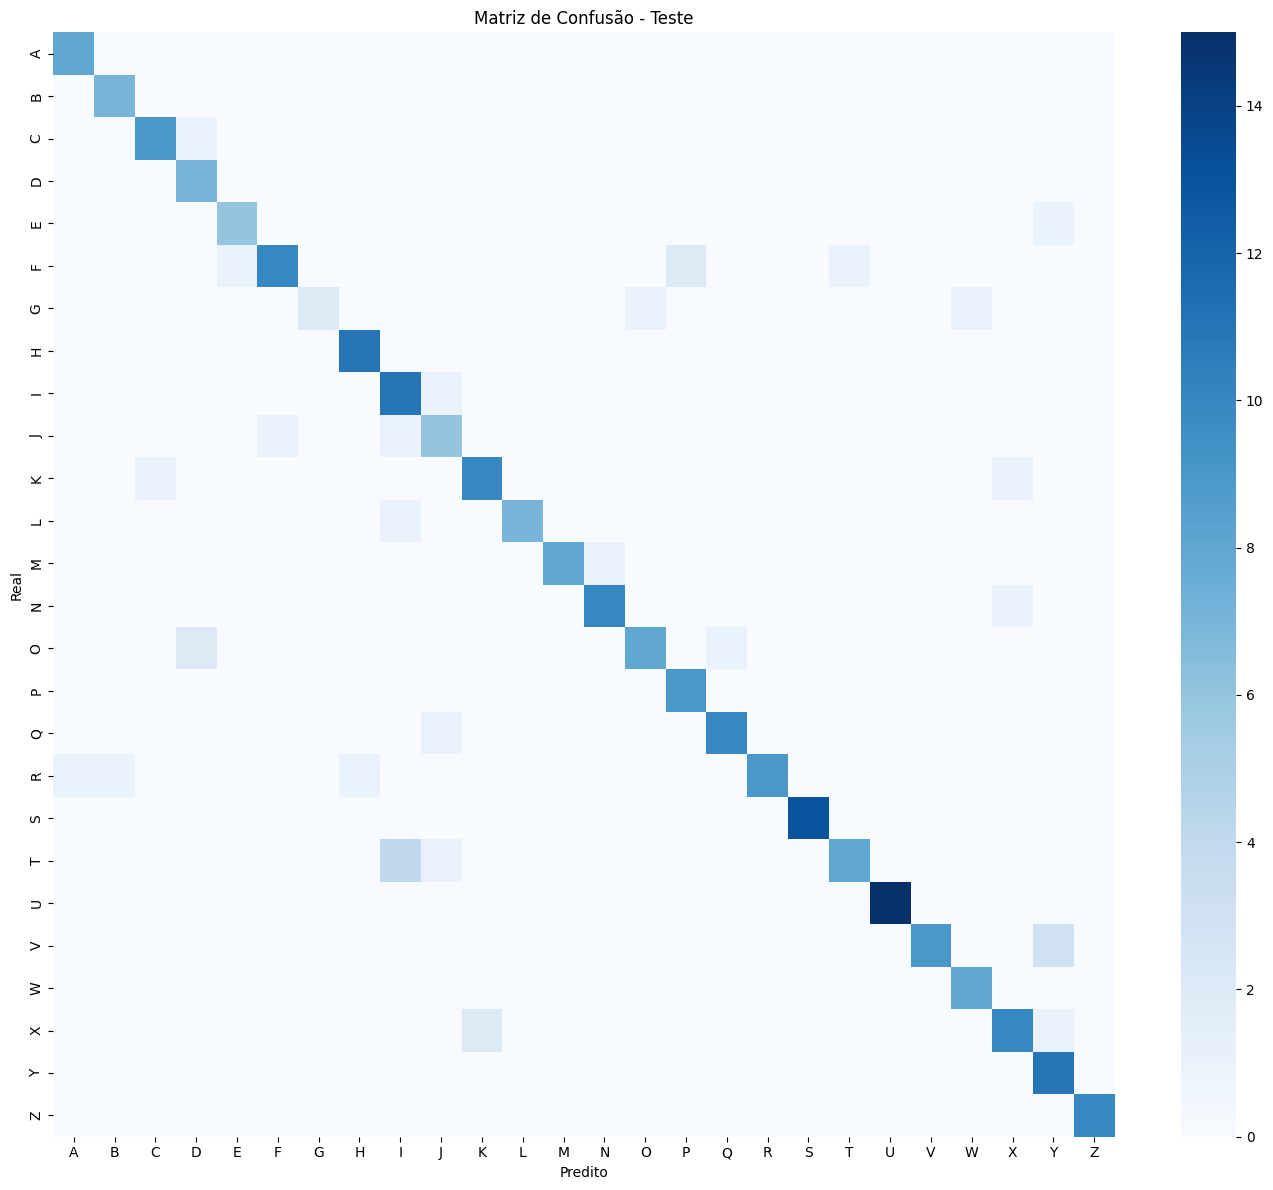


MATRIZ DE CONFUSÃO - LINHA A (linha 0)
Quando a verdade é A, o modelo previu:
  A: 8 vezes


In [ ]:
# ==============================
# MATRIZ DE CONFUSÃO
# ==============================

cm = confusion_matrix(y_test, predictions_test)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, annot=False, cmap='Blues', cbar=True, ax=ax)
ax.set_xlabel('Predito')
ax.set_ylabel('Real')
ax.set_title('Matriz de Confusão - Teste')
ax.set_xticklabels([chr(65+i) for i in range(26)])
ax.set_yticklabels([chr(65+i) for i in range(26)])
plt.tight_layout()
plt.show()




DISTRIBUIÇÃO DE CLASSES NOS DADOS DE TREINAMENTO
 Idx Letra  Qtd_Treino
  24     Y          30
   5     F          31
  23     X          31
   8     I          31
  19     T          32
  21     V          32
  18     S          32
   2     C          33
  20     U          34
  17     R          34
  13     N          34
   1     B          35
  14     O          35
  25     Z          36
   9     J          37
  10     K          37
  16     Q          38
  15     P          38
  12     M          38
   4     E          38
  11     L          39
  22     W          40
   7     H          40
   3     D          40
   0     A          41
   6     G          42


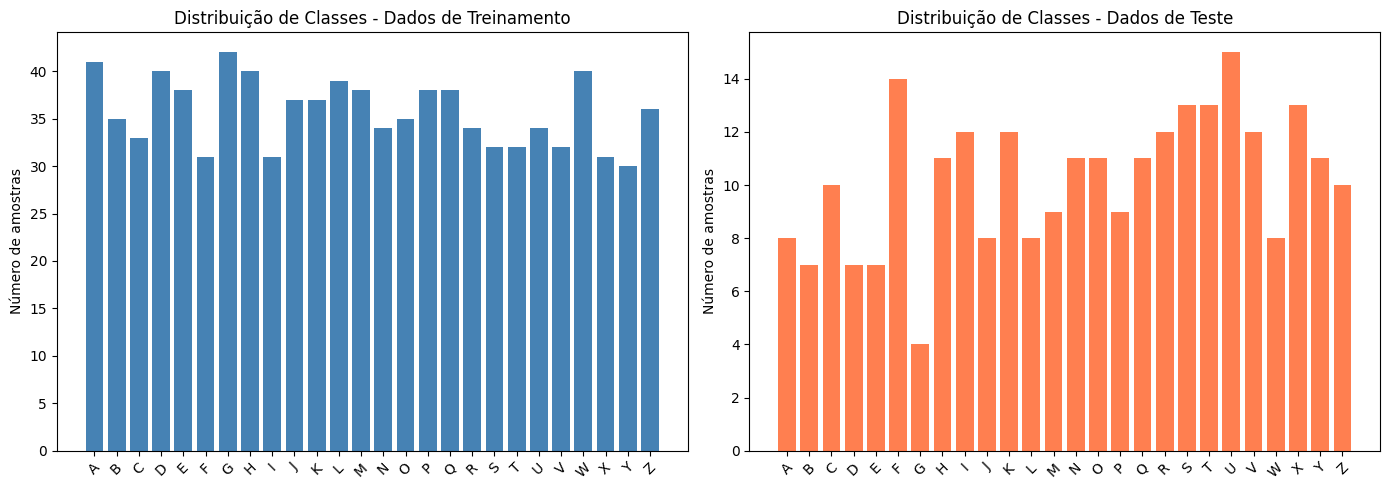


Classe A (0) no treinamento: 41 amostras
Classe A (0) no teste: 8 amostras

Média de amostras por classe (treino): 35.7
Classe A está 0.87x acima da média


In [ ]:
# ==============================
# ANÁLISE DE BALANCEAMENTO DE DADOS
# ==============================

print("\n" + "=" * 60)
print("DISTRIBUIÇÃO DE CLASSES NOS DADOS DE TREINAMENTO")
print("=" * 60)

class_counts_train = []
for i in range(26):
    count = (y_train == i).sum()
    class_counts_train.append((i, chr(65+i), count))

train_df = pd.DataFrame(class_counts_train, columns=['Idx', 'Letra', 'Qtd_Treino'])
print(train_df.sort_values('Qtd_Treino').to_string(index=False))

# Visualizar distribuição
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Treino
counts_train = [np.sum(y_train == i) for i in range(26)]
axes[0].bar([chr(65+i) for i in range(26)], counts_train, color='steelblue')
axes[0].set_title('Distribuição de Classes - Dados de Treinamento')
axes[0].set_ylabel('Número de amostras')
axes[0].tick_params(axis='x', rotation=45)

# Teste
counts_test = [np.sum(y_test == i) for i in range(26)]
axes[1].bar([chr(65+i) for i in range(26)], counts_test, color='coral')
axes[1].set_title('Distribuição de Classes - Dados de Teste')
axes[1].set_ylabel('Número de amostras')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

